# Valentina Garcia's Capstone project- exploritory data analysis

This code is for Valentina Garcia's capstone project for the Professional Certificate in Machine Learning and Artificial Intelligance
program offered by UC Berkeley. It is the first coding deliverable focused on exploritory data analysis.

In this project as a whole I will be examining analyzed proteomics data that was published as part of this paper: doi: 10.1186/s13068-026-02750-w.
In this data there is the percent protein abundace of endogenous and exogouns genes expressed in Rhodosporidium toruloides. Some of these 
samples have been transformed through lithium acetate, agrobactium mediated transformation, or both. Included with these samples is non-transformed controls. 

For a final deliverable, I will first use this data to model a classification problem to determine if I can predict which populations are engineered and by what method. In this assignment, I will end by generating an n-nearest neighbors model to act as a baseline for the final deliverable work.  

In the final deliverable, I also aim to see if I can predict the total expression level of introduced proteins using the expression of native proteins. I will try scaling the data appropriately, using Grid Search to find the right alpha, and Lasso to identify which native proteins are the best features. 



In [1]:
#Required imports
import pandas as pd
from pathlib import Path
import re
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import  StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import  KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import scipy.stats as stats
import zipfile
from pathlib import Path
import pandas as pd


## Data Ingestion, Cleaning, and Restructuring
At the end of this section will have two sets of data one containing all of the proteins measured and another just containing the endogenous R. toruloides proteins. For both some meta data will be included including the methadology for strain engineering or if there was no engineering.

In [2]:

# Unzip the folder
with zipfile.ZipFile("data.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

folder_path = Path("data")
df_list = []

# 1. rglob searches recursively through data/data/
# 2. 'not file.match("**/.__*")' safely skips Mac junk metadata files
csv_files = [f for f in folder_path.rglob("*.csv") if not f.name.startswith("._")]

for index, file in enumerate(csv_files, start=1):
    print(f"[{index}/{len(csv_files)}] Reading: {file.name}")
    temp_df = pd.read_csv(file)
    temp_df.insert(0, "source_file", file.name)
    df_list.append(temp_df)
    
if df_list:
    all_files_raw_df = pd.concat(df_list, ignore_index=True)
    print(f"\nDone! Combined {len(df_list)} CSV files into a DataFrame with {len(all_files_raw_df):,} total rows.")
else:
    print("No valid CSV files found to combine.")


[1/5] Reading: pPA212V1_Top3_Full_list_proteins_summary_20241002-162152.csv
[2/5] Reading: pPA212Top3_Full_list_proteins_summary_20250114-022452.csv
[3/5] Reading: pPA218Top3_Full_list_proteins_summary_20250115-063057.csv
[4/5] Reading: Top3_Full_list_proteins_summary_20241002-162152.csv
[5/5] Reading: pPA212V1pVEG23Top3_Full_list_proteins_summary_20241002-162152.csv

Done! Combined 5 CSV files into a DataFrame with 2,313,640 total rows.


In [3]:
#Looking at and evalutating the dataframe
# Display the first few rows
all_files_raw_df.head()


,source_file,Protein.Group,Protein.Names,Protein,Protein.Description,Sample,Top_3pep_counts_rep_mean,Top_3pep_counts_rep_std,%_of protein_abundance_Top3_rep_mean,%_of protein_abundance_Top3-rep_std,log10_%_abundance_rep_mean,log10_%_abundance_rep_std,CV%_of_%_protein_abundance,%_of protein_abundance_Top3_rep_mean_sem,Sample_size,Z-score
0,pPA212V1_Top3_Full_list_proteins_summary_20241...,A0A061AEQ7,A0A061AEQ7_RHOTO,Fgenesh:,40S ribosomal protein s18,MVA002_control2_144h_R1,2488882.000,NaN,0.190514,NaN,-0.720073,NaN,NaN,0.001897,310,0.571640
1,pPA212V1_Top3_Full_list_proteins_summary_20241...,A0A061AEQ7,A0A061AEQ7_RHOTO,Fgenesh:,40S ribosomal protein s18,MVA002_control2_144h_R2,2606241.333,NaN,0.203287,NaN,-0.691891,NaN,NaN,0.001897,310,0.954022
2,pPA212V1_Top3_Full_list_proteins_summary_20241...,A0A061AEQ7,A0A061AEQ7_RHOTO,Fgenesh:,40S ribosomal protein s18,MVA002_control2_144h_R3,2449625.000,NaN,0.188732,NaN,-0.724153,NaN,NaN,0.001897,310,0.518309
3,pPA212V1_Top3_Full_list_proteins_summary_20241...,A0A061AEQ7,A0A061AEQ7_RHOTO,Fgenesh:,40S ribosomal protein s18,MVA002_control2_288h_R1,2515083.667,NaN,0.182043,NaN,-0.739826,NaN,NaN,0.001897,310,0.318050
4,pPA212V1_Top3_Full_list_proteins_summary_20241...,A0A061AEQ7,A0A061AEQ7_RHOTO,Fgenesh:,40S ribosomal protein s18,MVA002_control2_288h_R2,2089414.667,NaN,0.144995,NaN,-0.838647,NaN,NaN,0.001897,310,-0.791061


In [4]:
#Cleaning the data
#Some of the columns in these data are empty but for somereason have a header, so will remove all columns where all values are nan
df_cleaning = all_files_raw_df.dropna(axis=1, how='all')

#merging the source_file and samlpe name to make restructuring easier; will have to seperate this back out later
df_cleaning['source_and_sample'] = df_cleaning['source_file'].astype(str).str.cat(
    df_cleaning['Sample'].astype(str), 
    sep='-ZZZ-'
)

#In this data there are a few different things measured. For the purposes of this modeling will look just at the percent of protein_abundance_Top3_rep_mean
df_cleaning = df_cleaning[['source_and_sample', 'Protein.Names','%_of protein_abundance_Top3_rep_mean']]




In [5]:
#Re-structuring
#Re-structuring the data so that the columns are the protein expression and the rows are different samples
df_pivoted_all_proteins = df_cleaning.pivot(
    index='source_and_sample',                      # Rows: unique samples
    columns='Protein.Names',                         # Columns: individual proteins
    values='%_of protein_abundance_Top3_rep_mean'    # Values: expression levels
).reset_index()

# Clean up column index name leftover from pivoting
df_pivoted_all_proteins.columns.name = None


#Since NaN is really equivelent to 0 percent, will make all remaing NaNs equal to 0
df_pivoted_all_proteins = df_pivoted_all_proteins.fillna(0)

df_pivoted_all_proteins.head()

,source_and_sample,A0A059XCF6_RHOTO,A0A061AEQ7_RHOTO,A0A061AEZ8_RHOTO,A0A061AF09_RHOTO,A0A061AF79_RHOTO,A0A061AGE6_RHOTO,A0A061AGL0_RHOTO,A0A061AH36_RHOTO,A0A061AHS5_RHOTO,...,K1C10_HUMAN,K1C9_HUMAN,K22E_HUMAN,K2C1_HUMAN,LYSC_CHICK,M7XN52_RHOT1,M7Y0N8_RHOT1,MVD1_YEAST,PPB_ECOLI,TRYP_PIG
0,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.190514,0.030702,0.0,0.081477,0.069653,0.037785,0.019680,0.0,...,0.011076,0.000513,0.000855,0.010589,0.0,0.0,0.0,0.001026,0.001026,0.420748
1,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.203287,0.031382,0.0,0.078028,0.050087,0.050967,0.015091,0.0,...,0.003202,0.000405,0.000675,0.000810,0.0,0.0,0.0,0.000810,0.000810,0.390853
2,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.188732,0.035307,0.0,0.081351,0.062335,0.034537,0.018030,0.0,...,0.004196,0.007348,0.000674,0.006349,0.0,0.0,0.0,0.000808,0.000808,0.326273
3,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.182043,0.025324,0.0,0.083504,0.052949,0.053442,0.023970,0.0,...,0.000769,0.000576,0.000961,0.001153,0.0,0.0,0.0,0.001153,0.001153,0.469750
4,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.144995,0.011057,0.0,0.080998,0.065513,0.042780,0.027335,0.0,...,0.000943,0.000708,0.001179,0.001415,0.0,0.0,0.0,0.004109,0.001415,0.604199


In [6]:
#Checking to make sure there wasn't any crazy data loss
print(all_files_raw_df['Protein.Names'].nunique())
print(df_cleaning['Protein.Names'].nunique())
print(len(df_pivoted_all_proteins.columns)-1)

#Since all three values match, have all of the expected columns

2257
2257
2257


In [7]:
#Now want to expand out to add the other features that are needed and are encapsulated in the source and sample name
#pull back out source
df_pivoted_all_proteins[['Source_file', 'Sample_name']] = df_pivoted_all_proteins['source_and_sample'].str.split('-ZZZ-', expand=True)


#The sample name includes a lot about the samples that need to be extracted out into features
#Extracting out strain
strains = ['WT', 'dCK', 'MVA002', 'MVA003']
pattern = f"({'|'.join(map(re.escape, strains))})"
df_pivoted_all_proteins['strain'] = df_pivoted_all_proteins['source_and_sample'].str.extract(pattern, flags=re.IGNORECASE, expand=False)

#Extracting out timepoint
time = ['144h', '288h']
pattern = f"({'|'.join(map(re.escape, time))})"
df_pivoted_all_proteins['time'] = df_pivoted_all_proteins['source_and_sample'].str.extract(pattern, flags=re.IGNORECASE, expand=False)

#Extracting out if there is a recent ATMT transformation
df_pivoted_all_proteins['ATMT_plasmid'] = df_pivoted_all_proteins['Sample_name'].str.split("_").str[1]

#Adding column that specifies engineering type based on the strain and ATMT_plasmid info

is_control = df_pivoted_all_proteins['ATMT_plasmid'].astype(str).str.contains('control', case=False, na=False)

conditions = [
    (df_pivoted_all_proteins['strain'] == 'WT') & is_control,
    (df_pivoted_all_proteins['strain'] == 'WT') & (~is_control),            # '~' means NOT control
    (df_pivoted_all_proteins['strain'] == 'dCK') & is_control,
    (df_pivoted_all_proteins['strain'] == 'dCK') & (~is_control),
    df_pivoted_all_proteins['strain'].isin(['MVA002']),
    df_pivoted_all_proteins['strain'].isin(['MVA003']),
]

choices = [
    'No Engineering',
    'ATMT',
    'Lithium Acetate',
    'Both',
    'ATMT',
    'Both'
]

df_pivoted_all_proteins['engineering_type'] = np.select(conditions, choices, default='Engineered / Plasmid')

df_pivoted_all_proteins.head()


,source_and_sample,A0A059XCF6_RHOTO,A0A061AEQ7_RHOTO,A0A061AEZ8_RHOTO,A0A061AF09_RHOTO,A0A061AF79_RHOTO,A0A061AGE6_RHOTO,A0A061AGL0_RHOTO,A0A061AH36_RHOTO,A0A061AHS5_RHOTO,...,M7Y0N8_RHOT1,MVD1_YEAST,PPB_ECOLI,TRYP_PIG,Source_file,Sample_name,strain,time,ATMT_plasmid,engineering_type
0,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.190514,0.030702,0.0,0.081477,0.069653,0.037785,0.019680,0.0,...,0.0,0.001026,0.001026,0.420748,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_144h_R1,MVA002,144h,control2,ATMT
1,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.203287,0.031382,0.0,0.078028,0.050087,0.050967,0.015091,0.0,...,0.0,0.000810,0.000810,0.390853,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_144h_R2,MVA002,144h,control2,ATMT
2,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.188732,0.035307,0.0,0.081351,0.062335,0.034537,0.018030,0.0,...,0.0,0.000808,0.000808,0.326273,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_144h_R3,MVA002,144h,control2,ATMT
3,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.182043,0.025324,0.0,0.083504,0.052949,0.053442,0.023970,0.0,...,0.0,0.001153,0.001153,0.469750,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_288h_R1,MVA002,288h,control2,ATMT
4,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.144995,0.011057,0.0,0.080998,0.065513,0.042780,0.027335,0.0,...,0.0,0.004109,0.001415,0.604199,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_288h_R2,MVA002,288h,control2,ATMT


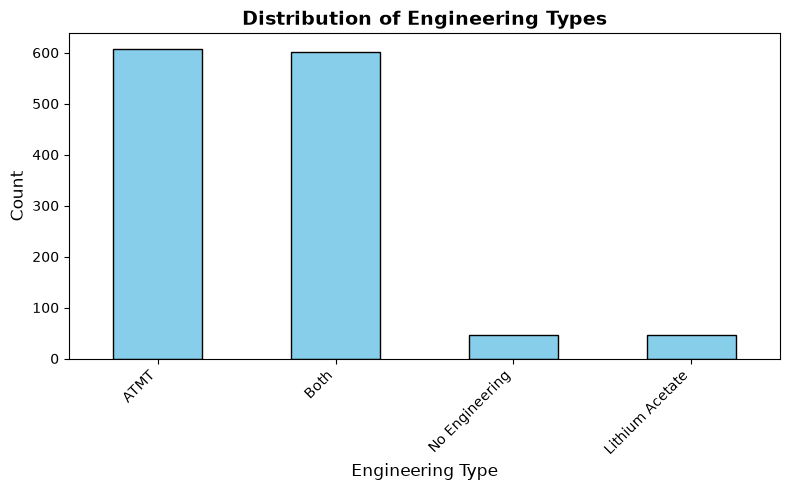

In [8]:
#Plotting how many of each type of engineering we have
counts = df_pivoted_all_proteins['engineering_type'].value_counts()
counts.plot(kind='bar', figsize=(8, 5), color='skyblue', edgecolor='black')
plt.title('Distribution of Engineering Types', fontsize=14, fontweight='bold')
plt.xlabel('Engineering Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotates labels so they do not overlap
plt.tight_layout()
plt.show()

In [9]:
#Since may want to look at just endogenous proteins, will make a dataframe that only has proteins that include RHOTO in the name
#since that indicates they are from the orgasism we are working with
df_pivoted_Rhodo_proteins = df_pivoted_all_proteins.filter(like='RHOTO')
df_pivoted_Rhodo_proteins[["source_and_sample", "Source_file", "Sample_name", 'strain', 'time', 'ATMT_plasmid', "engineering_type"]] = df_pivoted_all_proteins[[
   "source_and_sample", "Source_file", "Sample_name", 'strain', 'time', 'ATMT_plasmid', "engineering_type"
]]

X = df_pivoted_Rhodo_proteins.drop(['source_and_sample', 'Source_file', 'Sample_name', 'strain', 'time', 'ATMT_plasmid', 'engineering_type'], axis = 1)


In [10]:
df_pivoted_Rhodo_proteins

,A0A059XCF6_RHOTO,A0A061AEQ7_RHOTO,A0A061AEZ8_RHOTO,A0A061AF09_RHOTO,A0A061AF79_RHOTO,A0A061AGE6_RHOTO,A0A061AGL0_RHOTO,A0A061AH36_RHOTO,A0A061AHS5_RHOTO,A0A061AHU5_RHOTO,...,A0A2T0A5D2_RHOTO,A0A2T0AI07_RHOTO,G1APK3_RHOTO,source_and_sample,Source_file,Sample_name,strain,time,ATMT_plasmid,engineering_type
0,0.0,0.190514,0.030702,0.0,0.081477,0.069653,0.037785,0.019680,0.0,0.0,...,0.0,0.041821,0.233440,Top3_Full_list_proteins_summary_20241002-16215...,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_144h_R1,MVA002,144h,control2,ATMT
1,0.0,0.203287,0.031382,0.0,0.078028,0.050087,0.050967,0.015091,0.0,0.0,...,0.0,0.034156,0.229122,Top3_Full_list_proteins_summary_20241002-16215...,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_144h_R2,MVA002,144h,control2,ATMT
2,0.0,0.188732,0.035307,0.0,0.081351,0.062335,0.034537,0.018030,0.0,0.0,...,0.0,0.036461,0.215234,Top3_Full_list_proteins_summary_20241002-16215...,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_144h_R3,MVA002,144h,control2,ATMT
3,0.0,0.182043,0.025324,0.0,0.083504,0.052949,0.053442,0.023970,0.0,0.0,...,0.0,0.021405,0.243067,Top3_Full_list_proteins_summary_20241002-16215...,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_288h_R1,MVA002,288h,control2,ATMT
4,0.0,0.144995,0.011057,0.0,0.080998,0.065513,0.042780,0.027335,0.0,0.0,...,0.0,0.014130,0.253301,Top3_Full_list_proteins_summary_20241002-16215...,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_288h_R2,MVA002,288h,control2,ATMT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1299,0.0,0.234147,0.027117,0.0,0.122560,0.017045,0.038322,0.007227,0.0,0.0,...,0.0,0.000000,0.281885,pPA218Top3_Full_list_proteins_summary_20250115...,pPA218Top3_Full_list_proteins_summary_20250115...,216dCK_control2_144h_R2,dCK,144h,control2,Lithium Acetate
1300,0.0,0.278950,0.024176,0.0,0.102669,0.020710,0.040110,0.010704,0.0,0.0,...,0.0,0.000000,0.226843,pPA218Top3_Full_list_proteins_summary_20250115...,pPA218Top3_Full_list_proteins_summary_20250115...,217MVA002_control2_144h_R1,MVA002,144h,control2,ATMT
1301,0.0,0.273103,0.020006,0.0,0.102632,0.020680,0.040950,0.000704,0.0,0.0,...,0.0,0.000000,0.234320,pPA218Top3_Full_list_proteins_summary_20250115...,pPA218Top3_Full_list_proteins_summary_20250115...,217MVA002_control2_144h_R2,MVA002,144h,control2,ATMT
1302,0.0,0.235570,0.027230,0.0,0.125041,0.034560,0.044247,0.027680,0.0,0.0,...,0.0,0.000000,0.203471,pPA218Top3_Full_list_proteins_summary_20250115...,pPA218Top3_Full_list_proteins_summary_20250115...,218MVA003_control2_144h_R1,MVA003,144h,control2,Both


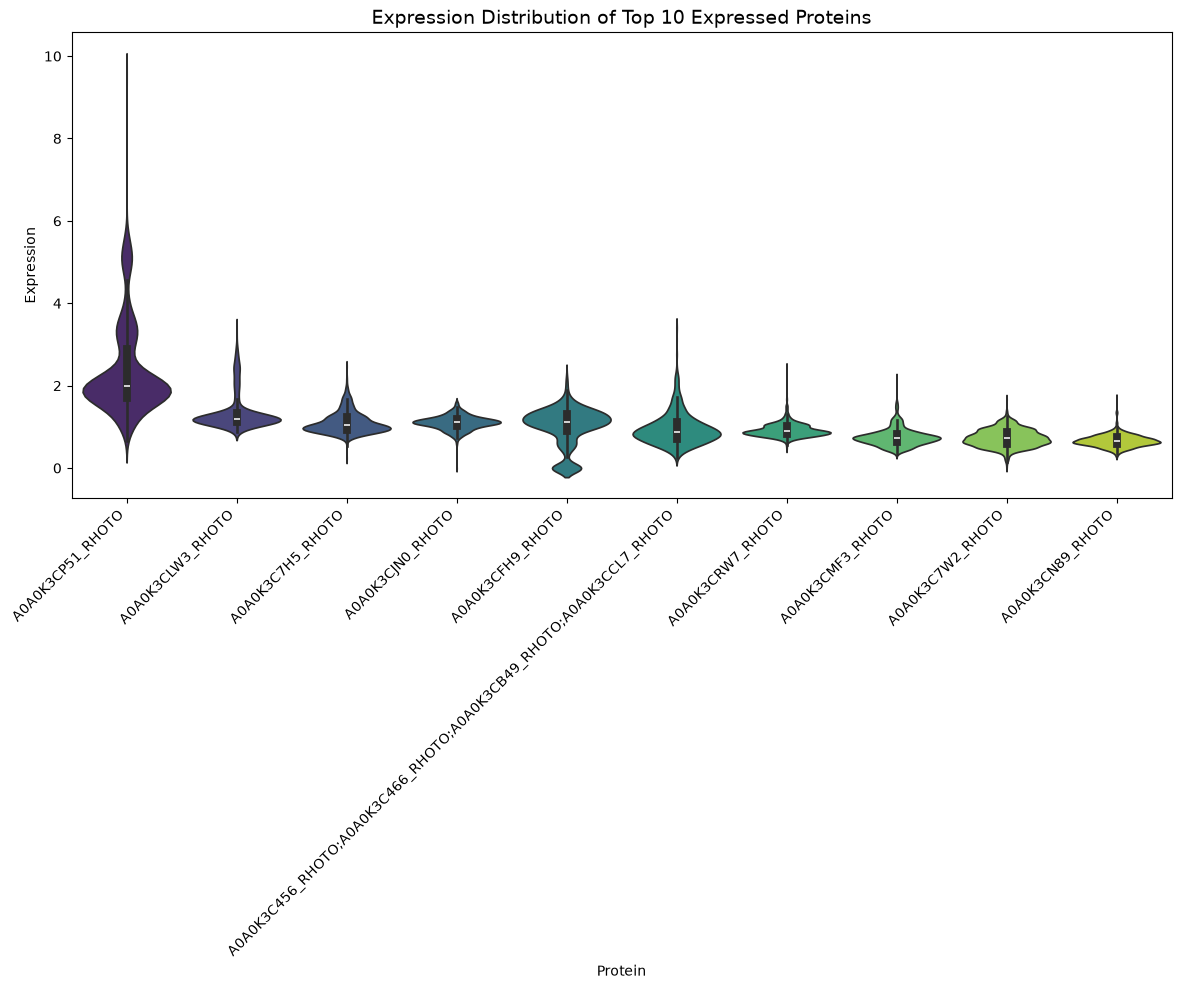

In [11]:
#Going to graph a violin plot of the top 10 expressed proteins to see if there is anything funny going on
top_10_proteins = X.mean().nlargest(10).index
df_top_10 = df_pivoted_Rhodo_proteins[top_10_proteins]
df_long = df_top_10.melt(var_name="Protein", value_name="Expression")

plt.figure(figsize=(12, 10))
sns.violinplot(
    data=df_long,
    x="Protein",
    y="Expression",
    hue="Protein",  # Avoids upcoming palette warning
    palette="viridis",
    legend=False,
)
plt.title("Expression Distribution of Top 10 Expressed Proteins", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

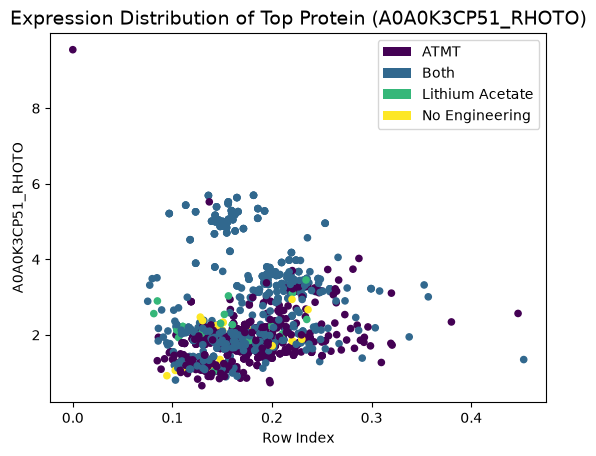

In [12]:
#Plotting a scatter plot of that top hi A0A0K3CP51_RHOTO to see how its distributed across engineering strains

df_pivoted_Rhodo_proteins.plot.scatter(x=1, y='A0A0K3CP51_RHOTO', c='engineering_type')
plt.xlabel('Row Index')
plt.title("Expression Distribution of Top Protein (A0A0K3CP51_RHOTO)", fontsize=14)
plt.show()

In [13]:
#Looking at z-scores across the endogenous proteins
df_zscore = df_pivoted_Rhodo_proteins.select_dtypes(include='number').apply(zscore)
df_zscore
extreme_outliers = (df_zscore > 3).sum().sum()
print(extreme_outliers)
print("Percent of extreme outliers in total data", extreme_outliers/2923568*100)

33871
Percent of extreme outliers in total data 1.1585501004252339


In [14]:
# Evaluate if the z-scores are evenly spread in the dataset using a chi-squared analysis
threshold = 3

outlier_mask = df_zscore.abs() > threshold
outliers_per_sample = outlier_mask.sum(axis=1)
total_outliers = outliers_per_sample.sum()
num_samples = len(outliers_per_sample)

if total_outliers > 0:
    expected_outliers = [total_outliers / num_samples] * num_samples
    
    # Calculate Chi-Square statistic and p-value
    chi2_stat, p_value = stats.chisquare(f_obs=outliers_per_sample, f_exp=expected_outliers)
    
    print(f"Total Outliers Found: {total_outliers}")
    print(f"Chi-Square Statistic: {chi2_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
else:
    print("No outliers detected across any samples.")


Total Outliers Found: 36625
Chi-Square Statistic: 127285.0407
P-value: 0.0000


## Modeling Efforts

### We will first look at modeling if we can classify the different engineering types

In [15]:
#Starting with efforts to see if can classify engineering type, therefore are going to start by using the data with just rhodo proteins.
#Split the data into features we want to use to model and the output we are modeling
y = df_pivoted_Rhodo_proteins.engineering_type
X_train, X_test, y_train, y_test = train_test_split(X, y)


In [16]:
#Starting by creating a dummy model
dummy_clf = DummyClassifier().fit(X_train, y_train)
baseline_training_score = dummy_clf.score(X_train, y_train)
baseline_test_score = dummy_clf.score(X_test, y_test)

#Creating a dataframe to start adding the performance metrics to 
model_performance = {
    'Model': [],
    'Train Accuracy': [],
    'Test Accuracy': []
}

model_performance = pd.DataFrame(model_performance)
model_performance.loc[len(model_performance)] = ['Dummy Pipeline', baseline_training_score,baseline_test_score]
model_performance

,Model,Train Accuracy,Test Accuracy
0,Dummy Pipeline,0.469325,0.43865


In [17]:
#Here we will build and test an KNN-nearest neighbors model using a grid search for the best parameters to establish a baseline model
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
])

knn_param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "minkowski"],
}

knn_search = GridSearchCV(knn_pipe, knn_param_grid, cv=5, scoring="accuracy", n_jobs=-1)

knn_search.fit(X_train, y_train)

knn_y_train_pred = knn_search.predict(X_train)
knn_y_test_pred = knn_search.predict(X_test)
knn_y_train_accuracy = accuracy_score(y_train, knn_y_train_pred)
knn_y_test_accuracy = accuracy_score(y_test, knn_y_test_pred)


In [18]:
#adding values from above to dataframe
model_performance.loc[len(model_performance)] = ['KNN Pipeline', knn_y_train_accuracy, knn_y_test_accuracy]
model_performance

,Model,Train Accuracy,Test Accuracy
0,Dummy Pipeline,0.469325,0.43865
1,KNN Pipeline,1.000000,0.91411
